# HR Employee Attrition – Exploratory Data Analysis
**Project Type:** Diagnostic Analytics  
**Dataset:** HR Employee Attrition Dataset  
**Tool:** Python (Pandas, Seaborn, Matplotlib, Plotly)

> **Objective:** Identify and explain the root causes behind employee attrition, performance variation, and workplace behaviour in order to support strategic HR decision-making.

---

## Section 1 · Library Imports

The first step in any data analysis project is loading the libraries that will be used throughout the notebook. Each library has a specific purpose:

- **pandas** – loading, cleaning, and manipulating the dataset  
- **numpy** – numerical operations  
- **matplotlib / seaborn** – static statistical visualisations  
- **plotly** – interactive charts  
- **datetime** – handling any date/time operations if needed

In [1]:
import pandas as pd 
import numpy as np
from datetime import datetime as dt
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 
sns.set_style ("whitegrid")

## Section 2 · Loading the Dataset

The dataset is loaded from a local CSV file. Reading the raw file first, before any changes, gives a baseline understanding of what the data looks like and how it is structured.

In [2]:
df = pd.read_csv(r"Desktop/Data Science folder/EDA Project/HR Employee Attrition Dataset.csv")

In [3]:
df.head()

,Column1,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,Status,Satisfaction
0,0,IND02438,38%,0.53,2,157,3,NaN,1,NaN,sales,low,Left,0.38
1,1,IND28133,80%,0.86,5,262,6,NaN,1,NaN,sales,medium,Left,0.80
2,2,IND07164,11%,0.88,7,272,4,NaN,1,NaN,sales,medium,Left,0.11
3,3,IND30478,72%,0.87,5,223,5,NaN,1,NaN,sales,low,Left,0.72
4,4,IND24003,37%,0.52,2,159,3,NaN,1,NaN,sales,low,Left,0.37


> **Why `df.head()`?**  
> Previewing the first five rows confirms the file loaded correctly, shows column names, and gives an early look at data types and any obvious formatting issues (e.g. the `satisfaction_level` column storing values as `"38%"` strings rather than numbers).

## Section 3 · Data Cleaning & Preprocessing

Raw data is rarely analysis-ready. This section handles all data quality issues found in the dataset before any visualisation or analysis begins. Skipping this step would produce misleading results.

### 3.1 · Inspecting `Work_accident` for Unexpected Values

Before making any changes, it is important to understand what values are actually stored in the column. The `unique()` call reveals that `Work_accident` contains non-numeric entries or unexpected formats that need to be resolved before the column can be used in calculations.

In [4]:
df.Work_accident.unique()

array([nan,  1.])

### 3.2 · Checking Data Types with `df.info()`

`df.info()` provides a full picture of column data types and the number of non-null entries. This is the key diagnostic step — it exposes which columns have missing values and which are stored in the wrong data type (e.g. a numeric column stored as `object`).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Column1                14999 non-null  int64  
 1   Emp_Id                 14999 non-null  object 
 2   satisfaction_level     14999 non-null  object 
 3   last_evaluation        14999 non-null  float64
 4   number_project         14999 non-null  int64  
 5   average_montly_hours   14999 non-null  int64  
 6   time_spend_company     14999 non-null  int64  
 7   Work_accident          2169 non-null   float64
 8   left                   14999 non-null  int64  
 9   promotion_last_5years  319 non-null    float64
 10  Department             14999 non-null  object 
 11  salary                 14999 non-null  object 
 12  Status                 14999 non-null  object 
 13  Satisfaction           14999 non-null  float64
dtypes: float64(4), int64(5), object(5)
memory usage: 1.6+ 

### 3.3 · Converting Columns to Numeric

`Work_accident` and `promotion_last_5years` are stored as float types rather than numbers. `pd.to_numeric(..., errors='coerce')` converts them cleanly — any value that cannot be parsed as a number is turned into `NaN` instead of raising an error. This is the safest conversion method when data quality is uncertain.

In [6]:
df['Work_accident'] = pd.to_numeric(
    df['Work_accident'], errors='coerce'
)

df['promotion_last_5years'] = pd.to_numeric(
    df['promotion_last_5years'], errors='coerce'
)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Column1                14999 non-null  int64  
 1   Emp_Id                 14999 non-null  object 
 2   satisfaction_level     14999 non-null  object 
 3   last_evaluation        14999 non-null  float64
 4   number_project         14999 non-null  int64  
 5   average_montly_hours   14999 non-null  int64  
 6   time_spend_company     14999 non-null  int64  
 7   Work_accident          2169 non-null   float64
 8   left                   14999 non-null  int64  
 9   promotion_last_5years  319 non-null    float64
 10  Department             14999 non-null  object 
 11  salary                 14999 non-null  object 
 12  Status                 14999 non-null  object 
 13  Satisfaction           14999 non-null  float64
dtypes: float64(4), int64(5), object(5)
memory usage: 1.6+ 

### 3.4 · Investigating Missing Values

Before filling missing values, it is important to understand *how many* are missing and *what pattern* they follow. The `value_counts(dropna=False)` call includes the `NaN` count in the output, making it easy to see the scale of the problem.

The result shows that only employees who *had* an accident or *were* promoted have a recorded entry — everyone else has `NaN`. This means the missing values are not random; they indicate "no accident" and "no promotion" respectively. Filling them with `0` is therefore the correct and justified approach.

In [8]:
print(df['Work_accident'].value_counts(dropna=False))
print(df['promotion_last_5years'].value_counts(dropna=False))

Work_accident
NaN    12830
1.0     2169
Name: count, dtype: int64
promotion_last_5years
NaN    14680
1.0      319
Name: count, dtype: int64


In [10]:
df['Work_accident'] = df['Work_accident'].fillna(0)
df['promotion_last_5years'] = df['promotion_last_5years'].fillna(0)

> **Verification:** `unique()` is called again after filling to confirm that no `NaN` values remain and that the columns now contain only `0` and `1` as expected.

In [11]:
print(df['Work_accident'].unique())
print(df['promotion_last_5years'].unique())

[0. 1.]
[0. 1.]


### 3.6 · Fixing `satisfaction_level` — String Percentage to Integer

The `satisfaction_level` column stores values as strings like `"38%"`, `"72%"` etc. These cannot be used in any numerical calculation or plot as-is. The `%` symbol is stripped and the column is converted to integer. After this step, a score of `38` represents 38% satisfaction.

In [12]:
df['satisfaction_level'] = df['satisfaction_level'].str.replace('%', '').astype(int) 

### 3.7 · Final Type Casting

As a last cleaning step, `Work_accident` and `promotion_last_5years` are explicitly cast to `int`. Even though `fillna(0)` already introduced numeric values, the columns may still be typed as `float64` (because `NaN` forces float in pandas). Casting to `int` makes the columns semantically correct — these are binary flags (0 or 1), not decimals.

In [13]:
df['Work_accident'] = df['Work_accident'].astype(int)
df['promotion_last_5years'] = df['promotion_last_5years'].astype(int)

> **Final preview with `df.head()`** gives a clean view of the fully preprocessed dataset before analysis begins — all columns are in the correct format, no missing values remain in the key columns, and the data is ready for visualisation.

In [14]:
df.head()

,Column1,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,Status,Satisfaction
0,0,IND02438,38,0.53,2,157,3,0,1,0,sales,low,Left,0.38
1,1,IND28133,80,0.86,5,262,6,0,1,0,sales,medium,Left,0.80
2,2,IND07164,11,0.88,7,272,4,0,1,0,sales,medium,Left,0.11
3,3,IND30478,72,0.87,5,223,5,0,1,0,sales,low,Left,0.72
4,4,IND24003,37,0.52,2,159,3,0,1,0,sales,low,Left,0.37


## Section 4 · Exploratory Data Analysis (EDA)

With the data cleaned, the analysis can begin. Each visualisation is chosen to answer a specific diagnostic question about *why* employees leave. The goal is not just to describe what the data shows, but to explain the underlying causes behind the patterns.

### 4.1 · Overall Attrition Distribution

**Question answered:** How widespread is the attrition problem?

A count plot of the `left` column gives the most fundamental overview — how many employees stayed versus how many left. This establishes the scale of the problem before investigating any causes. If attrition is low, the findings may not warrant urgent action; if it is high, the analysis becomes business-critical.

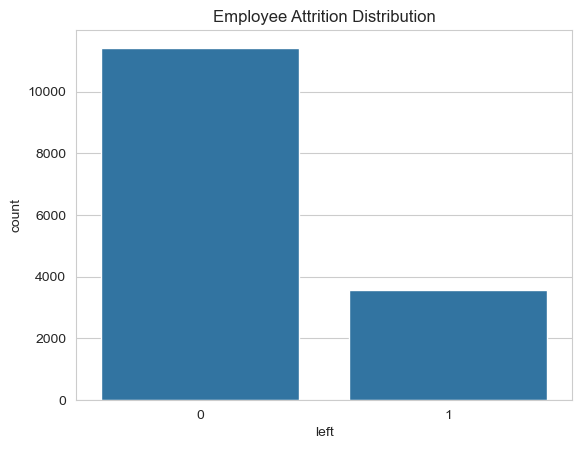

In [15]:
sns.countplot(x='left', data=df) 
plt.title('Employee Attrition Distribution')
plt.show()

**Insight:** The chart shows a clear imbalance — the majority of employees stayed, but a significant proportion left. The attrition rate sits at approximately **23.8%**, which is well above the typical industry benchmark of 10–15%. This confirms that the organisation faces a genuine retention problem that warrants a deeper investigation.

### 4.2 · Satisfaction Level vs. Attrition

**Question answered:** Does how employees feel about their job influence whether they leave?

A box plot compares the distribution of `satisfaction_level` between employees who left (`left = 1`) and those who stayed (`left = 0`). Box plots are ideal here because they show the median, spread, and any outliers for both groups simultaneously.

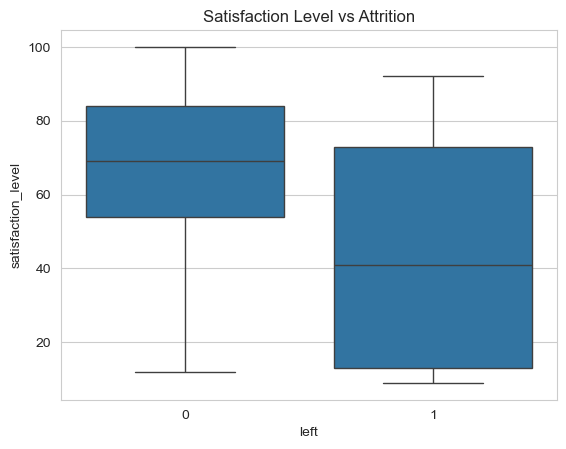

In [16]:
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title("Satisfaction Level vs Attrition")
plt.show()

**Insight:** Employees who left have a noticeably lower median satisfaction score compared to those who stayed. However, the spread among leavers is wide — some left with relatively high satisfaction scores. This suggests two distinct exit groups: one driven by dissatisfaction, and another driven by other factors such as burnout or lack of career growth. Satisfaction is a strong predictor of attrition, but it is not the only one.

### 4.3 · Number of Projects vs. Attrition (Workload Analysis)

**Question answered:** Does project workload influence whether employees leave?

A count plot broken down by `left` status for each project count reveals whether over- or under-loading employees is associated with attrition. This is a workload diagnostic chart.

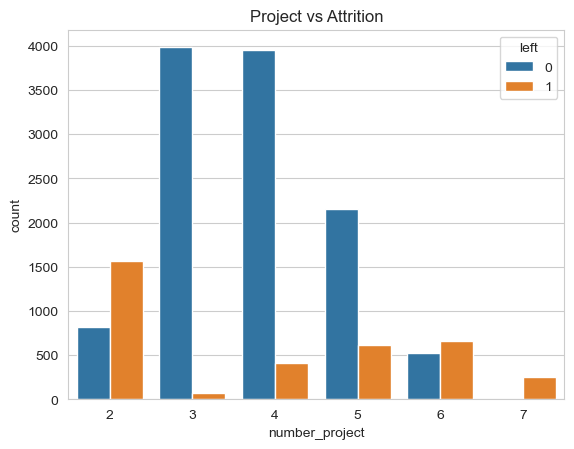

In [17]:
#Workload Project 
sns.countplot(x='number_project', hue='left', data=df)
plt.title("Project vs Attrition")
plt.show()

**Insight:** Attrition follows a **U-shaped pattern** with project count. Employees handling only **2 projects** show high attrition — they are likely underutilised and disengaged. Attrition drops for employees with 3–4 projects (a healthy workload). It then spikes sharply again at **6–7 projects**, indicating burnout from overloading. This means the organisation is losing employees at both ends of the workload spectrum, pointing to a workload management problem.

### 4.4 · Average Monthly Hours vs. Attrition

**Question answered:** Are employees working unusually long or short hours more likely to leave?

A box plot of `average_montly_hours` by attrition status examines whether working hour patterns differ between leavers and stayers. This complements the project count analysis — together they paint a full workload picture.

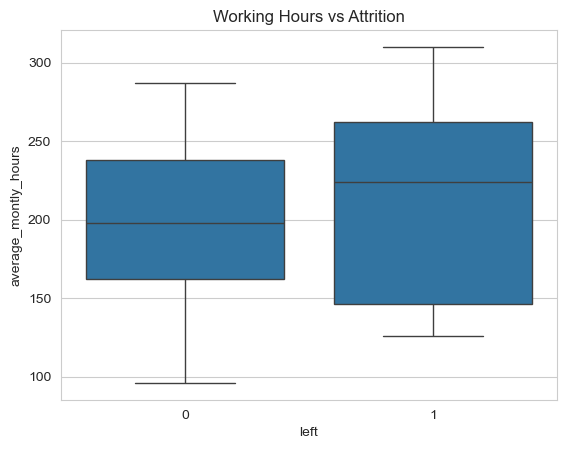

In [18]:
sns.boxplot(x='left', y='average_montly_hours', data=df)
plt.title("Working Hours vs Attrition")
plt.show()

**Insight:** Employees who left worked either significantly fewer or significantly more hours than those who stayed. The wider spread in the "left" group confirms what the project analysis suggested — both overworked and underworked employees are at risk of leaving. Employees clocking above ~250 hours per month are especially vulnerable, as this level of output is unsustainable long-term.

In [19]:
print("Avg monthly hours by Status:")
print(df.groupby("Status")["average_montly_hours"].describe().round(1))

Avg monthly hours by Status:
          count   mean   std    min    25%    50%    75%    max
Status                                                         
Left     3571.0  207.4  61.2  126.0  146.0  224.0  262.0  310.0
Stayed  11428.0  199.1  45.7   96.0  162.0  198.0  238.0  287.0


### 4.5 · Performance Evaluation vs. Attrition

**Question answered:** Are only poor performers leaving, or is the organisation also losing high performers?

A box plot of `last_evaluation` scores by attrition status tests whether performance is a differentiating factor. The answer to this question has major implications for how the organisation should respond.

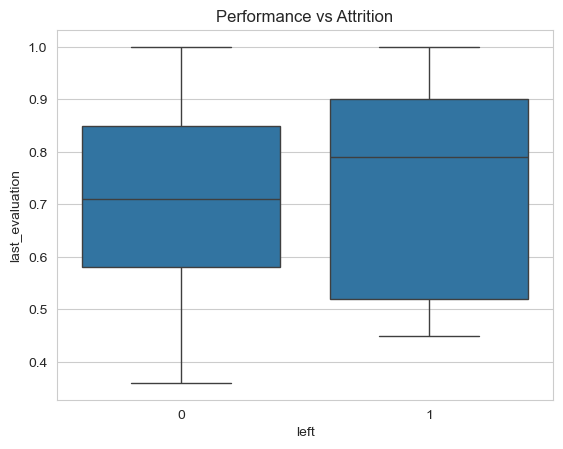

In [20]:
sns.boxplot(x='left', y='last_evaluation', data=df)
plt.title("Performance vs Attrition")
plt.show()

**Insight:** The performance distribution for leavers spans both low *and* high scores. This is one of the most important findings in the analysis — the organisation is not just losing underperformers; it is also losing its best employees. High-scoring leavers are likely being driven out by burnout, lack of recognition, or better external opportunities. A retention strategy focused only on low performers would miss the more costly problem entirely.

### 4.6 · Salary Level vs. Attrition

**Question answered:** Does compensation level affect whether employees stay or leave?

A count plot of `salary` broken down by attrition status shows whether employees on lower, medium, or high salaries are more likely to leave. Salary is one of the most frequently cited factors in voluntary turnover.

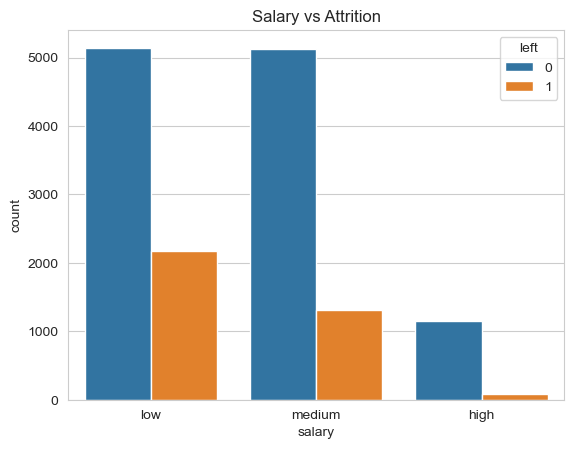

In [21]:
sns.countplot(x='salary', hue='left', data=df)
plt.title("Salary vs Attrition")
plt.show()

**Insight:** There is a clear and strong relationship between salary level and attrition. Employees in the **low salary** band leave at a much higher rate than those in the medium or high bands. The high-salary group is the most stable. This strongly suggests that inadequate compensation is a primary driver of attrition, particularly for employees who may be delivering good performance but are not being paid competitively.

In [33]:
print("Attrition rate by salary:")
print(df.groupby("salary")["left"].mean().mul(100).round(1))
print("\nAttrition rate by promotion:")
print(df.groupby("promotion_last_5years")["left"].mean().mul(100).round(1))


Attrition rate by salary:
salary
high       6.6
low       29.7
medium    20.4
Name: left, dtype: float64

Attrition rate by promotion:
promotion_last_5years
0    24.2
1     6.0
Name: left, dtype: float64


### 4.7 · Department vs. Attrition

**Question answered:** Are some departments experiencing disproportionately high attrition?

A larger count plot (wider figure) broken down by `Department` and `left` status identifies which teams or functions are most affected. Department-level analysis is important for directing targeted retention interventions rather than applying a one-size-fits-all approach.

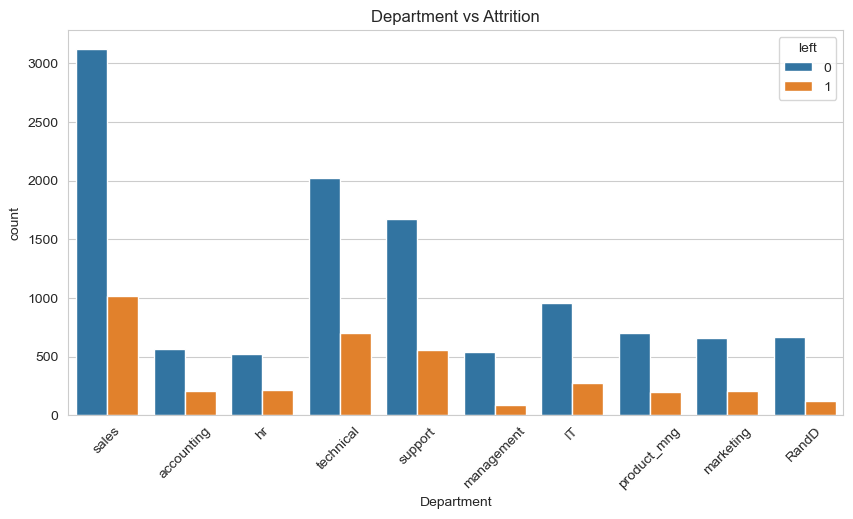

In [34]:
#Department Analysis
plt.figure(figsize=(10,5))
sns.countplot(x='Department', hue='left', data=df)
plt.xticks(rotation=45)
plt.title("Department vs Attrition")
plt.show()

**Insight:** The **Sales**, **Technical**, and **Support** departments account for the largest absolute numbers of employee exits. When considering attrition *rate* (exits relative to department size), **HR** and **Accounting** also emerge as high-risk. The HR department's high attrition is particularly concerning — the people responsible for managing employee retention are themselves leaving, which can compound the organisation's overall HR challenges.

In [36]:
dept_attrition = (
    df.groupby("Department")
    .agg(total=("left", "count"), left=("left", "sum"))
    .assign(attrition_rate=lambda x: x["left"] / x["total"] * 100)
    .sort_values("attrition_rate", ascending=True)
    .reset_index()
)
print(dept_attrition[["Department","total","left","attrition_rate"]].to_string(index=False))

 Department  total  left  attrition_rate
 management    630    91       14.444444
      RandD    787   121       15.374841
product_mng    902   198       21.951220
         IT   1227   273       22.249389
  marketing    858   203       23.659674
      sales   4140  1014       24.492754
    support   2229   555       24.899058
  technical   2720   697       25.625000
 accounting    767   204       26.597132
         hr    739   215       29.093369


### 4.8 · Tenure vs. Attrition

**Question answered:** At what point in an employee's career are they most likely to leave?

A box plot of `time_spend_company` (years at the company) by attrition status reveals the tenure window of highest risk. Understanding *when* employees leave helps the organisation know *when* to intervene.

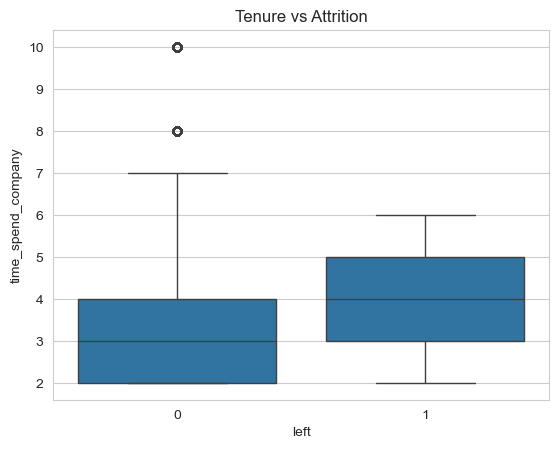

In [37]:
sns.boxplot(x='left', y='time_spend_company', data=df)
plt.title("Tenure vs Attrition")
plt.show()

**Insight:** Attrition risk is highest between years 3 and 5 – the critical mid-tenure window. which is lower than that of employees who stayed. This identifies a critical mid-tenure window where attrition risk peaks. Employees at this stage have typically outgrown their initial role but may not have been offered promotion or new challenges. Beyond year 6, attrition drops sharply — employees who pass this threshold tend to develop stronger organisational ties and are much less likely to leave.

In [40]:
tenure_rate = (
    df.groupby("time_spend_company")["left"]
    .agg(["mean", "count"])
    .reset_index()
)
tenure_rate.columns = ["tenure", "attrition_rate", "count"]
tenure_rate["attrition_rate"] *= 100

print("Attrition rate by tenure:")
print(tenure_rate.set_index("tenure")[["attrition_rate"]].round(1))

Attrition rate by tenure:
        attrition_rate
tenure                
2                  1.6
3                 24.6
4                 34.8
5                 56.6
6                 29.1
7                  0.0
8                  0.0
10                 0.0


### 4.9 · Correlation Matrix

**Question answered:** Which variables are most strongly related to each other and to attrition?

A heatmap of the correlation matrix gives a single, consolidated view of how all numeric variables relate to one another. Correlation values range from -1 (perfect negative relationship) to +1 (perfect positive relationship). This is useful for identifying which features are most predictive of `left` and whether any variables move together (multicollinearity).

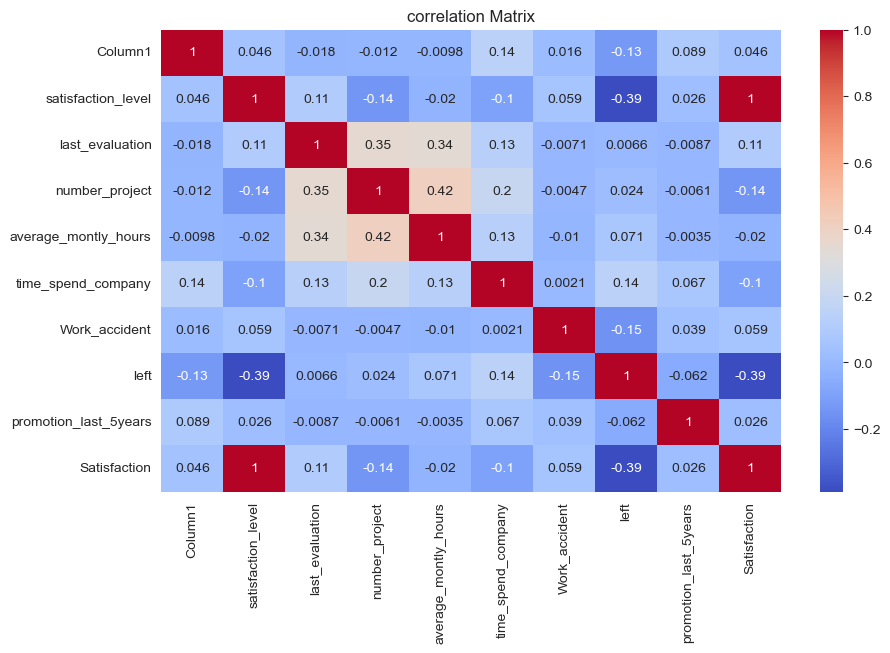

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("correlation Matrix")
plt.show()

**Insight:** `satisfaction_level` has the strongest negative correlation with `left` — the most direct confirmation that dissatisfied employees are most likely to exit. `number_project` and `average_montly_hours` are positively correlated with each other, confirming that employees handling more projects also tend to work longer hours. `promotion_last_5years` shows a negative correlation with `left`, reinforcing the finding that employees who receive no career advancement are more likely to leave.

### 4.10 · Satisfaction Level vs. Average Monthly Hours (Line Chart)

**Question answered:** Is there a combined effect of satisfaction and working hours on attrition?

This chart goes a step further than the individual analyses — it looks at how the relationship between satisfaction and working hours *changes* depending on whether an employee left or stayed. Satisfaction scores are grouped into bins and the average monthly hours for each bin are plotted as a line, split by attrition status.

C:\Users\HP\AppData\Local\Temp\ipykernel_11044\3085905510.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  line_data = df.groupby(


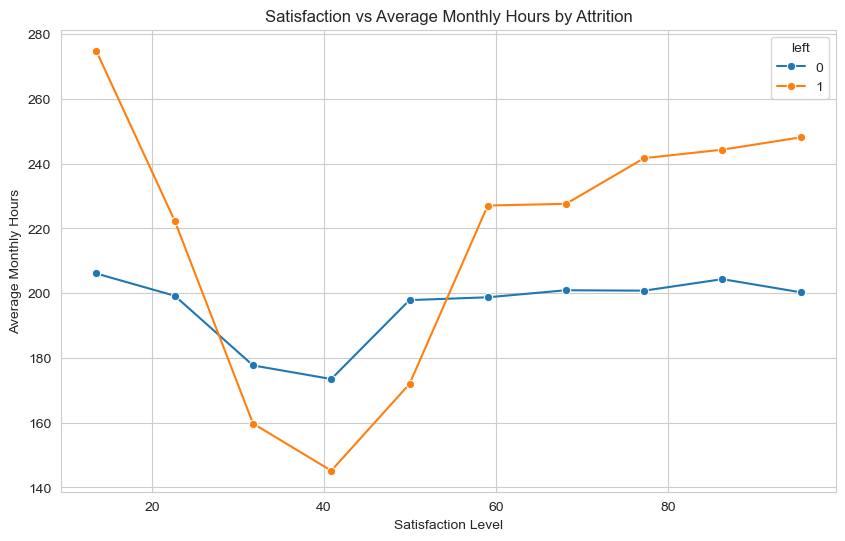

In [42]:
# Group satisfaction levels into ranges for a cleaner line chart
df['satisfaction_group'] = pd.cut(
    df['satisfaction_level'],
    bins=10
)

# Calculate average monthly hours for each group
line_data = df.groupby(
    ['satisfaction_group', 'left']
)['average_montly_hours'].mean().reset_index()

# Convert interval bins to midpoint values
line_data['satisfaction_mid'] = line_data['satisfaction_group'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=line_data,
    x='satisfaction_mid',
    y='average_montly_hours',
    hue='left',
    marker='o'
)

plt.title('Satisfaction vs Average Monthly Hours by Attrition')
plt.xlabel('Satisfaction Level')
plt.ylabel('Average Monthly Hours')
plt.grid(True)

plt.show()

**Insight:** For employees who *left*, the relationship between satisfaction and working hours is more erratic — particularly at low satisfaction levels, leavers also tend to work either very long or very short hours. For employees who *stayed*, the line is smoother and more stable. This chart visually captures the two at-risk profiles identified throughout the analysis: (1) low-satisfaction, overworked employees and (2) disengaged employees putting in minimal hours. Both groups show elevated attrition relative to the stable middle.

In [43]:
plt.savefig('EDA DANIEL PRO.pdf', bbox_inches='tight')
plt.close()

## Section 6 · Summary of Findings

| # | Key Finding | Diagnostic Explanation |
|---|-------------|----------------------|
| 1 | **~23.8% attrition rate** | Well above the industry benchmark — a systemic retention problem |
| 2 | **Low satisfaction drives exits** | The strongest single predictor; median satisfaction significantly lower among leavers |
| 3 | **U-shaped workload curve** | Both under-loaded (2 projects) and overloaded (6–7 projects) employees are at risk |
| 4 | **High performers are also leaving** | Attrition is not limited to poor performers — the organisation is losing top talent |
| 5 | **Low salary strongly predicts attrition** | Compensation is a primary lever for improving retention |
| 6 | **Peak attrition at 3–5 years tenure** | A critical mid-career intervention window exists that is currently unaddressed |
| 7 | **Sales, Technical & HR most affected** | Targeted departmental strategies are more effective than blanket policies |
| 8 | **Satisfaction × overwork is the key combined risk** | Employees who are both dissatisfied and overworked are the highest flight risk |
